In [1]:
import pandas as pd

In [2]:
df=pd.read_excel(r'C:\Anthime.PERROT\1_Thèse\X_all_scripts\Theo_Rossi_Script_GluSnfr\PCA_Notebooks_Data\GluSnFR_avg_variables_allCa_filtered_3sigma.xlsx', sheet_name=1)
df_1_5Ca=pd.read_excel(r'C:\Anthime.PERROT\1_Thèse\X_all_scripts\Theo_Rossi_Script_GluSnfr\PCA_Notebooks_Data\GluSnFR_avg_variables_Ca_paired_filtered_3sigma.xlsx', sheet_name=0)
df_4Ca=pd.read_excel(r'C:\Anthime.PERROT\1_Thèse\X_all_scripts\Theo_Rossi_Script_GluSnfr\PCA_Notebooks_Data\GluSnFR_avg_variables_Ca_paired_filtered_3sigma.xlsx', sheet_name=1)

In [3]:
new_df=df.drop(['ID', 'AMP3','AMP4','AMP5','AMP6','AMP7','AMP8','AMP9','AMP10','%Fail3'], axis=1) 
new_df_1_5Ca=df_1_5Ca.drop(['ID', 'AMP3','AMP4','AMP5','AMP6','AMP7','AMP8','AMP9','AMP10','%Fail3'], axis=1) 
new_df_4Ca=df_4Ca.drop(['ID', 'AMP3','AMP4','AMP5','AMP6','AMP7','AMP8','AMP9','AMP10','%Fail3'], axis=1) 
labels = new_df.columns

In [4]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [5]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(new_df)
scaled_data_1_5_mM = scaler.transform(new_df_1_5Ca)
scaled_data_4_mM = scaler.transform(new_df_4Ca)
pca = PCA(n_components=2)
transformed_data = pca.fit_transform(scaled_data)
transformed_data_1_5_mM = pca.transform(scaled_data_1_5_mM)
transformed_data_4_mM =  pca.transform(scaled_data_4_mM)

# Create a new DataFrame with the transformed data
transformed_df = pd.DataFrame(transformed_data, columns=[f"PC{i+1}" for i in range(transformed_data.shape[1])])
transformed_df_1_5_mM = pd.DataFrame(transformed_data_1_5_mM, columns=[f"PC{i+1}" for i in range(transformed_data.shape[1])])
transformed_df_4_mM = pd.DataFrame(transformed_data_4_mM, columns=[f"PC{i+1}" for i in range(transformed_data.shape[1])])

ValueError: could not convert string to float: 'UN'

In [27]:
#transformed_df_1_5_mM

In [28]:
print(" explained variance: ", pca.explained_variance_ratio_)
print (" pca components:  ", pca.components_)

 explained variance:  [0.5839683  0.20241261]
 pca components:   [[-0.21626655 -0.10425017  0.26062109  0.30888819  0.3250216   0.33037407
   0.32494576  0.3244983   0.32272136  0.32402288  0.32460522  0.19475338
   0.03021806]
 [ 0.421354    0.5419031   0.16057509  0.11551893  0.11459304  0.04833366
   0.05712486  0.0801919   0.06728836  0.07736981  0.07661815 -0.43070571
  -0.51246425]]


In [30]:
df_components = pd.DataFrame(pca.components_, columns = labels, index = ['PC_1', 'PC_2'])
#df_components

In [31]:
full_table=pd.concat([transformed_df, new_df], axis=1, join='inner')
#full_table

In [32]:
full_table_df=full_table.corr()

In [33]:
coeff_corr=full_table_df.iloc[0:2,2:]
#coeff_corr

In [35]:
from sklearn.cluster import KMeans
n_clusters = 5

# Apply K-Means clustering
kmeans = KMeans(n_clusters=n_clusters, n_init= 'auto')
kmeans.fit(transformed_df)
# Get the cluster labels
cluster_labels = kmeans.labels_
# Add the cluster labels to the transformed DataFrame
transformed_df['Cluster'] = cluster_labels
# Print the transformed DataFrame with the cluster labels
#print(transformed_df.head())

C:\Users\Philippe.ISOPE\anaconda3\envs\jupyterlab4\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


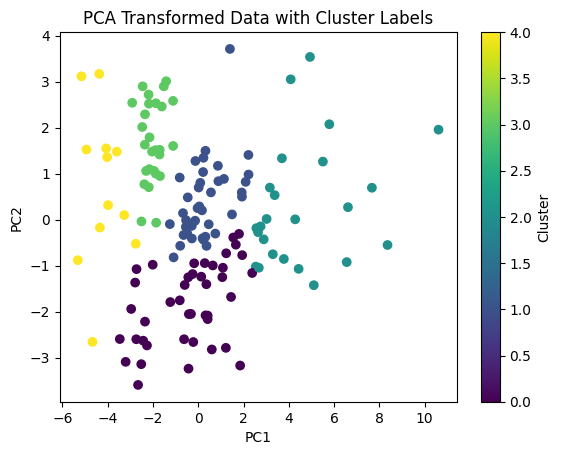

In [36]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

plt.scatter(transformed_df['PC1'], transformed_df['PC2'], c=transformed_df['Cluster'], cmap='viridis')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Transformed Data with Cluster Labels')
plt.colorbar(label='Cluster')
plt.show
plt.savefig('PCA.pdf')

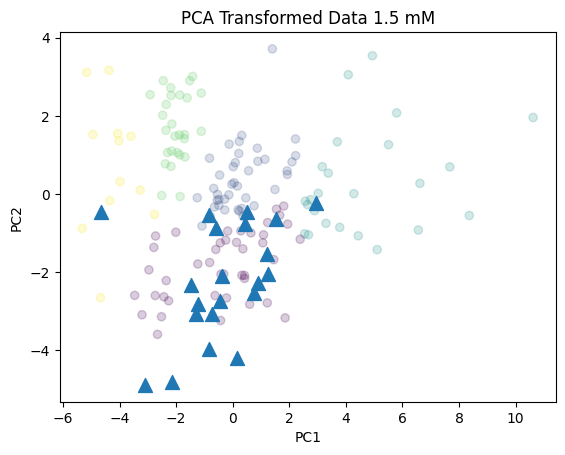

In [37]:
plt.scatter(transformed_df['PC1'], transformed_df['PC2'], c=transformed_df['Cluster'], cmap='viridis', alpha=.2)
plt.scatter(transformed_df_1_5_mM['PC1'], transformed_df_1_5_mM['PC2'],marker='^', s=100)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Transformed Data 1.5 mM')
plt.show
plt.savefig('PCA 1_5,.pdf')

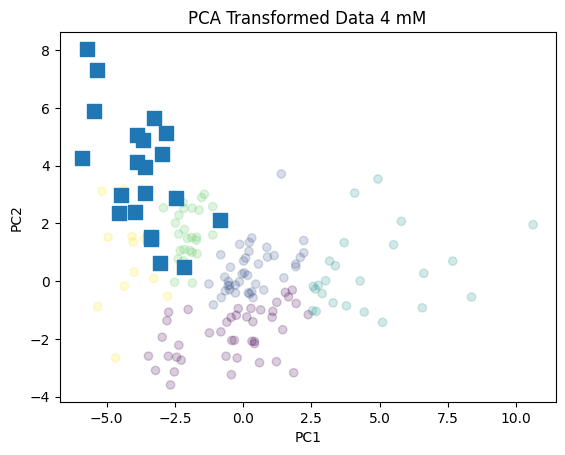

In [38]:
plt.scatter(transformed_df['PC1'], transformed_df['PC2'], c=transformed_df['Cluster'], cmap='viridis', alpha=.2)
plt.scatter(transformed_df_4_mM['PC1'], transformed_df_4_mM['PC2'],marker='s', s=100)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Transformed Data 4 mM')
plt.show
plt.savefig('PCA 4 mM,.pdf')

In [44]:
#transformed_df